In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import os
from pathlib import Path
import sys 
from matplotlib.colors import ListedColormap, BoundaryNorm

import_path = Path.cwd().parents[1]
sys.path.insert(0, str(import_path))
import feature_utils as futils

In [2]:
root = Path(r"E:\segs_clust_7079")
pc = "pc_4096"
k = "k_08"

Z2 = np.load(root / pc / "pca2_scores.npy")
labels = np.load(root / pc / k / "segment_labels.npy")

In [3]:
with np.load(root / "segments_ipca.npz") as z:
    for key in z.files:
        print(f"{key}: {z[key].shape}")

with np.load(root / "segments_ipca.npz") as z:
    evr = z["explained_variance_ratio"]
    

ipca_components: (4096, 15300)
ipca_mean: (15300,)
scaler_mean: (15300,)
scaler_scale: (15300,)
explained_variance: (4096,)
explained_variance_ratio: (4096,)
n_components: ()


In [11]:
print("Explained variance ratios:", evr*100)

Explained variance ratios: [9.1740585e+01 1.1243222e+00 3.6121196e-01 ... 2.7519578e-04 2.7438407e-04
 2.7416303e-04]


Cumulative explained variance:
[0.91740584 0.92864907 0.93226117 0.9343935  0.9360839  0.93700004
 0.93769056 0.93832856]


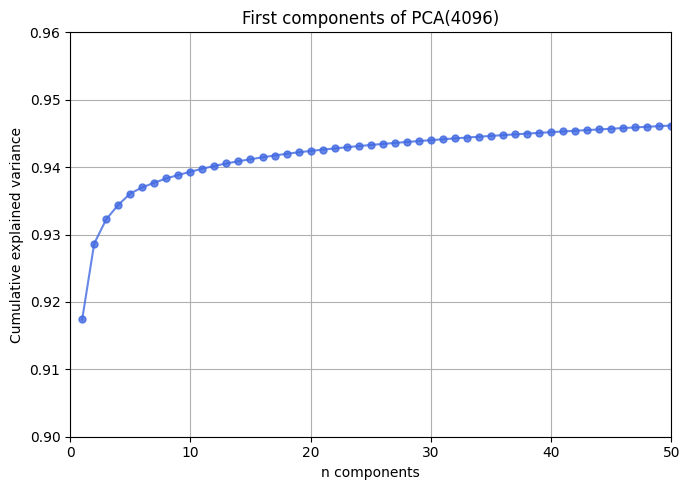

In [6]:
report_fig_path = r"C:\Users\Lindholm\Dropbox\BSc\report_figures" 
cumu_evr = np.cumsum(evr)
print("Cumulative explained variance:")
print(cumu_evr[0:8])
# eig_vals = pca.explained_variance_.astype(np.float32)

fig, ax = plt.subplots(figsize=(7, 5))
k = 50
ax.plot(np.arange(1, k+1), cumu_evr[0:k], marker="o", markersize=5, color="royalblue", alpha=0.8)
ax.set_xlabel("n components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("First components of PCA(4096)")
ax.set_xlim(0, k)
ax.set_ylim(0.90, 0.96)
ax.grid()
plt.tight_layout()
plt.savefig(Path(report_fig_path) / "pca_exp_cumuvar.png", dpi=300)
plt.show()